In [1]:
from experiments.dj.result_tables import FlowPriorResult
from experiments.dj.prior_tables import FlowPriorConfig
from experiments.dj.dataloader_tables import DataLoaderConfig
from experiments.dj.trainer_tables import FPTrainerConfig
from task_transfer.evaluation.evaluate_generative_model import evaluate_flow_prior
from task_transfer.ml_lib.data_loading import build_dataloaders

import torch

[2024-05-31 14:44:25,485][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-05-31 14:44:25,580][INFO]: Connected sshrinivasan@134.76.19.44:3306


In [2]:
fp_cols = [col for col in FlowPriorConfig.heading if col != 'id']
dl_cols = [col for col in DataLoaderConfig.heading if col != 'id']
trainer_cols = [col for col in FPTrainerConfig.heading if col != 'id']

result_table = FlowPriorResult() * FlowPriorConfig.proj(fp_id="id", *fp_cols) * DataLoaderConfig.proj(dl_id="id", *dl_cols) * FPTrainerConfig.proj(trainer_id="id", *trainer_cols)

In [3]:
result_table

fp_id,trainer_id,dl_id,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem,tracker_output,eval_output,model,seed,flow_depth,flow_initial_nonlin flow direction is data -> latent,flow_final_nonlin,flow_nonlin,flow_base_dist,affine_type,data_fname,train_prop,val_prop,lr,weight_decay,n_epochs,batch_size,early_stopping_threshold,early_stopping_patience
0173a9aecec7a4e144011e0d3ff0c8a7,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-52.199527740478516,1.2041391134262085,-52.2991943359375,2.289771556854248,-52.2991943359375,2.289771556854248,=BLOB=,=BLOB=,=BLOB=,42,2,inv_softplus,none,tanh,normal,full,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2,0.001,0.001,250,128,10,10
0626e82eec85ade7041703d85e168d5b,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-123.26030731201172,1.62436842918396,-123.29173278808594,3.0070111751556396,-123.29173278808594,3.0070111751556396,=BLOB=,=BLOB=,=BLOB=,42,3,inv_softplus,none,leaky_relu,normal,factorized,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2,0.001,0.001,250,128,10,10
0ca2aadbd204c4e82604881cb610f139,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-594692096.0,132690160.0,-592236160.0,249797216.0,-592236160.0,249797216.0,=BLOB=,=BLOB=,=BLOB=,100,3,inv_softplus,none,leaky_relu,normal,full,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2,0.001,0.001,250,128,10,10
16901c461ff0ccf8f2b5e22bcba8899c,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-52.234161376953125,1.2203691005706787,-52.35736846923828,2.3031113147735596,-52.35736846923828,2.3031113147735596,=BLOB=,=BLOB=,=BLOB=,100,2,inv_softplus,none,tanh,normal,full,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2,0.001,0.001,250,128,10,10
186db1e9aa2b1e3a61dcc662710e350a,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-130.90750122070312,1.726919174194336,-131.0658721923828,3.1596803665161133,-131.0658721923828,3.1596803665161133,=BLOB=,=BLOB=,=BLOB=,100,3,inv_softplus,none,leaky_relu,multivariate_normal,factorized,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2,0.001,0.001,250,128,10,10
1c09ed5bbe5a009aa5b23f10ad64dc47,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-155.95053100585938,1.9786127805709839,-155.7195281982422,3.6979401111602783,-155.7195281982422,3.6979401111602783,=BLOB=,=BLOB=,=BLOB=,42,3,inv_softplus,none,leaky_relu,multivariate_normal,factorized,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2,0.001,0.001,250,128,10,10
2e02964f416edf99fa4d43c661e27f41,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-134.7959442138672,1.989512324333191,-134.9379425048828,3.7226223945617676,-134.9379425048828,3.7226223945617676,=BLOB=,=BLOB=,=BLOB=,42,2,inv_softplus,none,leaky_relu,multivariate_normal,factorized,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2,0.001,0.001,250,128,10,10
30bb7c40ad0da0ddd2952450eff30afc,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-128.96951293945312,1.7380419969558716,-128.73252868652344,3.310781717300415,-128.73252868652344,3.310781717300415,=BLOB=,=BLOB=,=BLOB=,100,2,inv_softplus,none,leaky_relu,multivariate_normal,factorized,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2,0.001,0.001,250,128,10,10
372321e3e1e8bd827744c2f521eb598c,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-220.7942352294922,22.762653350830078,-228.9904022216797,42.64375305175781,-228.9904022216797,42.64375305175781,=BLOB=,=BLOB=,=BLOB=,42,3,inv_softplus,none,tanh,normal,full,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0

In [4]:
key = result_table.fetch("KEY")[0]

In [5]:
result = (result_table & key).fetch1(download_path="/tmp")

In [6]:
result

{'fp_id': '0173a9aecec7a4e144011e0d3ff0c8a7',
 'trainer_id': 'f89651063b51487dcdf4041336ef89db',
 'dl_id': '260a5ea8175f75eaef132f42873ad14a',
 'train_ll_mean': -52.199527740478516,
 'train_ll_sem': 1.2041391134262085,
 'val_ll_mean': -52.2991943359375,
 'val_ll_sem': 2.289771556854248,
 'test_ll_mean': -52.2991943359375,
 'test_ll_sem': 2.289771556854248,
 'tracker_output': '/tmp/0173a9aecec7a4e144011e0d3ff0c8a7_f89651063b51487dcdf4041336ef89db_260a5ea8175f75eaef132f42873ad14a_tracker_output.pkl',
 'eval_output': '/tmp/0173a9aecec7a4e144011e0d3ff0c8a7_f89651063b51487dcdf4041336ef89db_260a5ea8175f75eaef132f42873ad14a_eval_output.pkl',
 'model': '/tmp/0173a9aecec7a4e144011e0d3ff0c8a7_f89651063b51487dcdf4041336ef89db_260a5ea8175f75eaef132f42873ad14a_model.pt',
 'seed': 42,
 'flow_depth': 2,
 'flow_initial_nonlin': 'inv_softplus',
 'flow_final_nonlin': 'none',
 'flow_nonlin': 'tanh',
 'flow_base_dist': 'normal',
 'affine_type': 'full',
 'data_fname': '/src/project/data/synthetic/haefner_2

In [7]:
flow_path = result["model"]
flow_model = torch.load(flow_path)
flow_model.eval()
data_path = result["data_fname"]
train_prop = result["train_prop"]
val_prop = result["val_prop"]
batch_size = result["batch_size"]
train_loader, val_loader, test_loader = build_dataloaders(
    data_path, train_prop, val_prop, batch_size
)

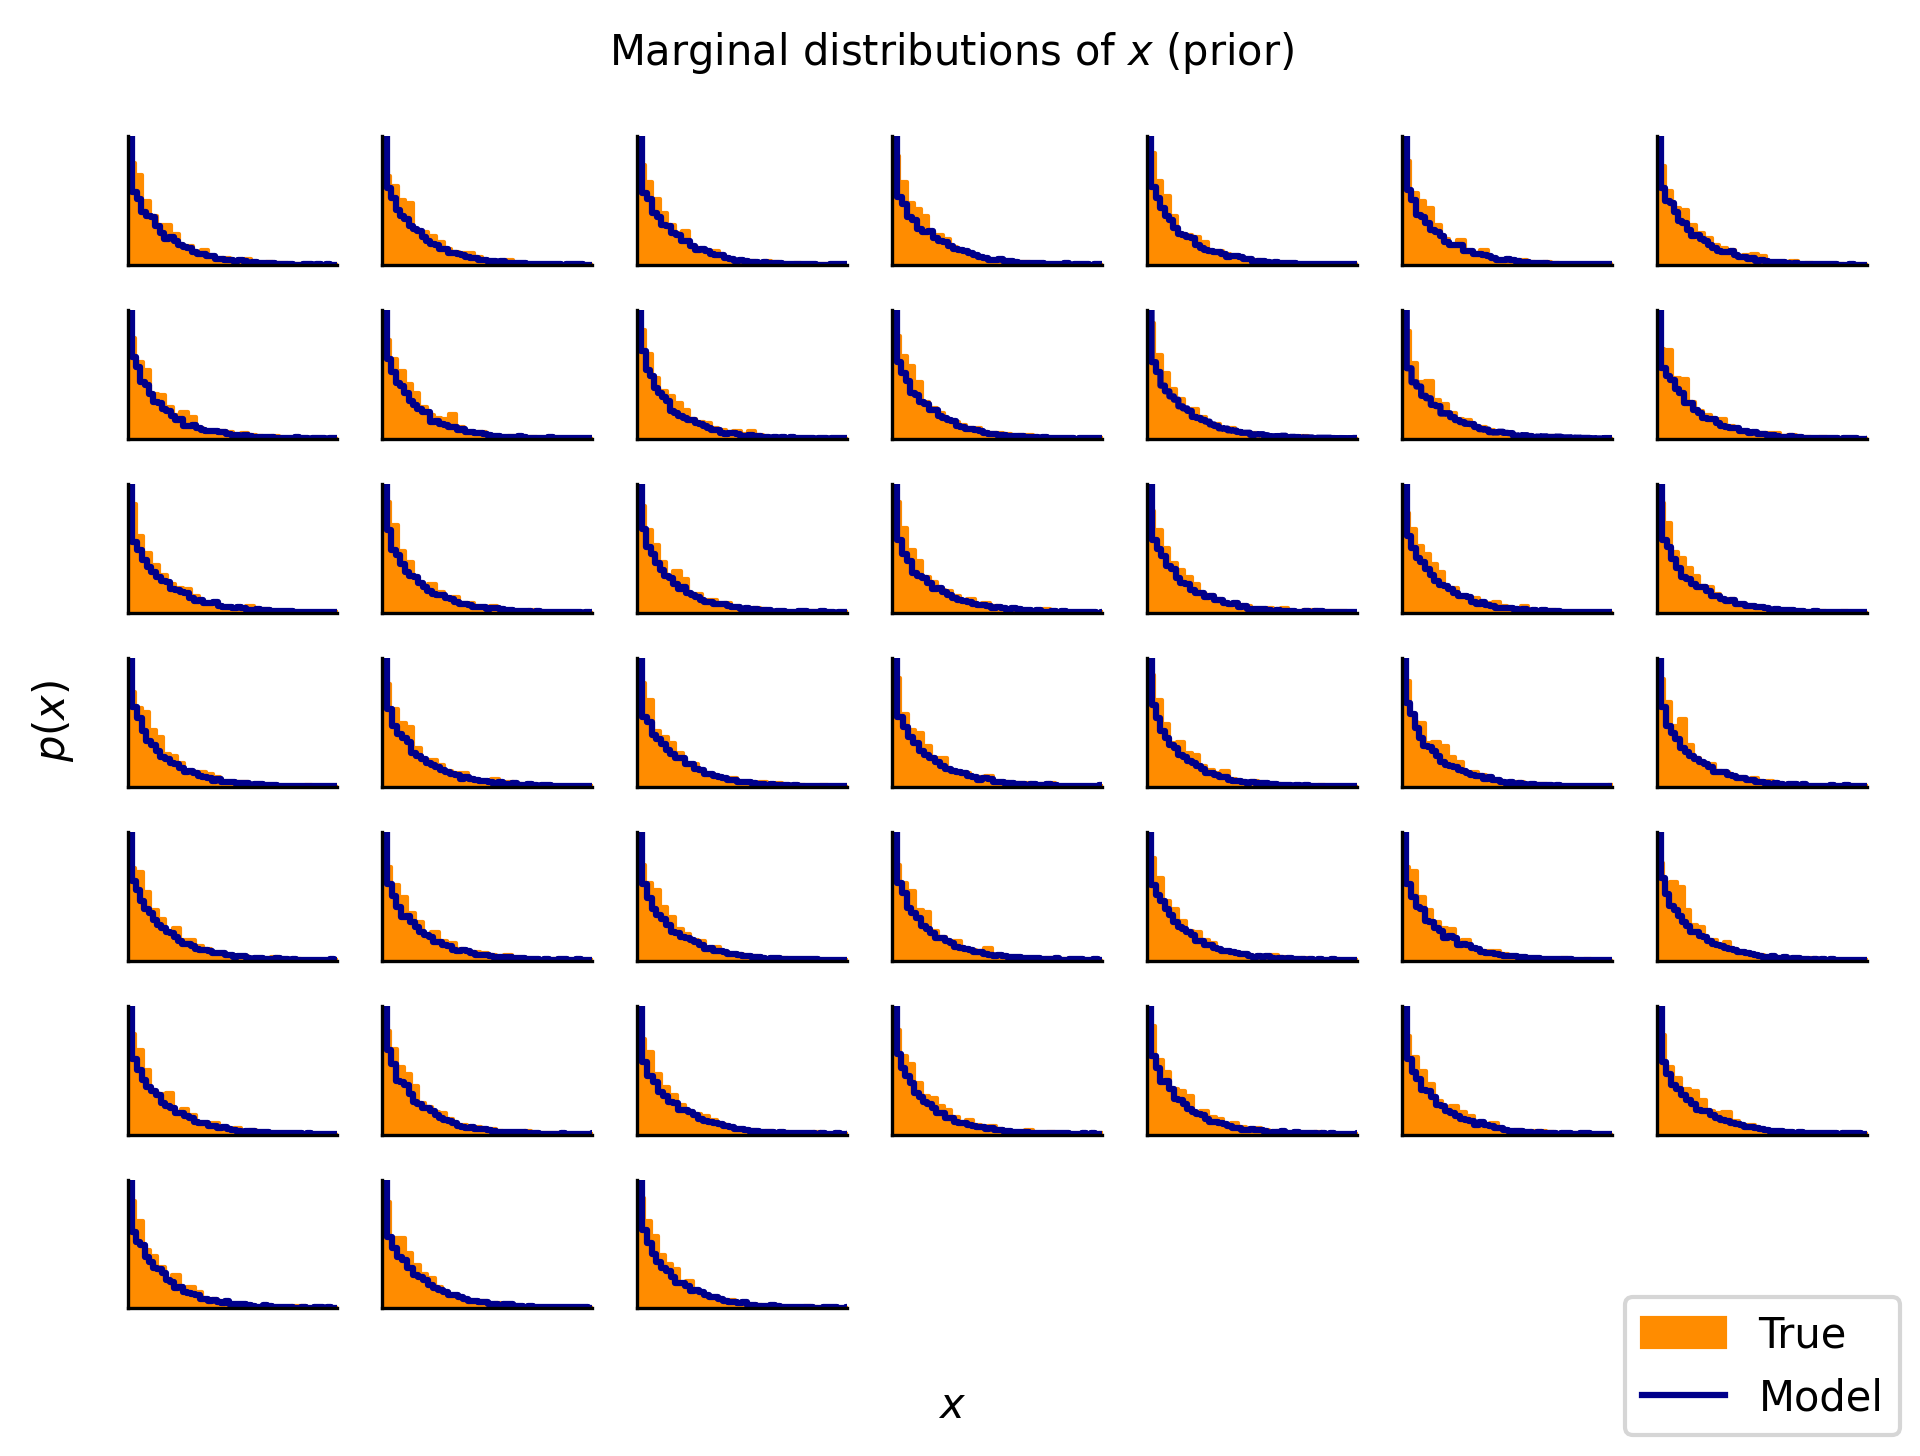

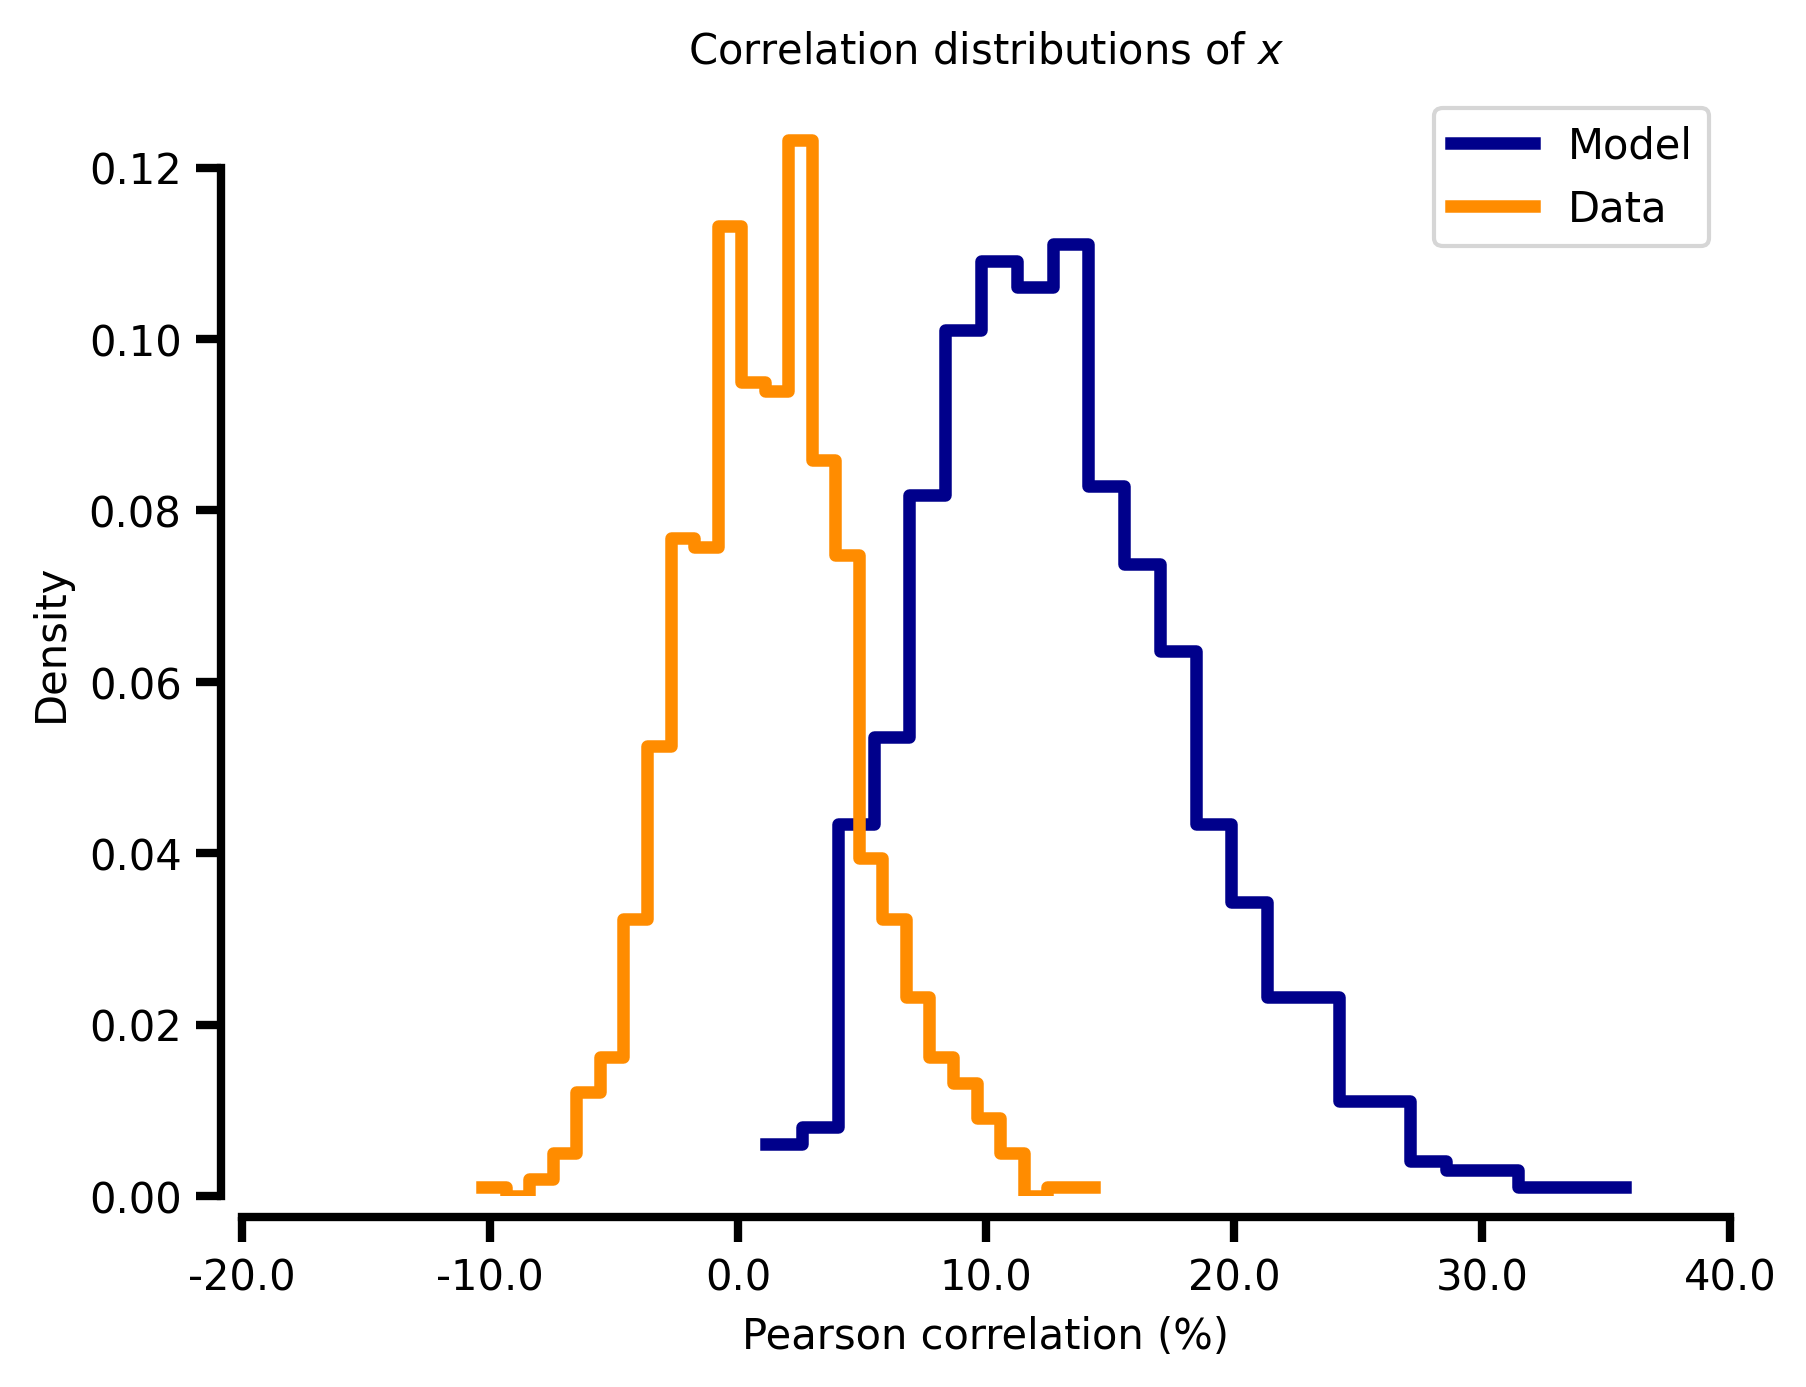

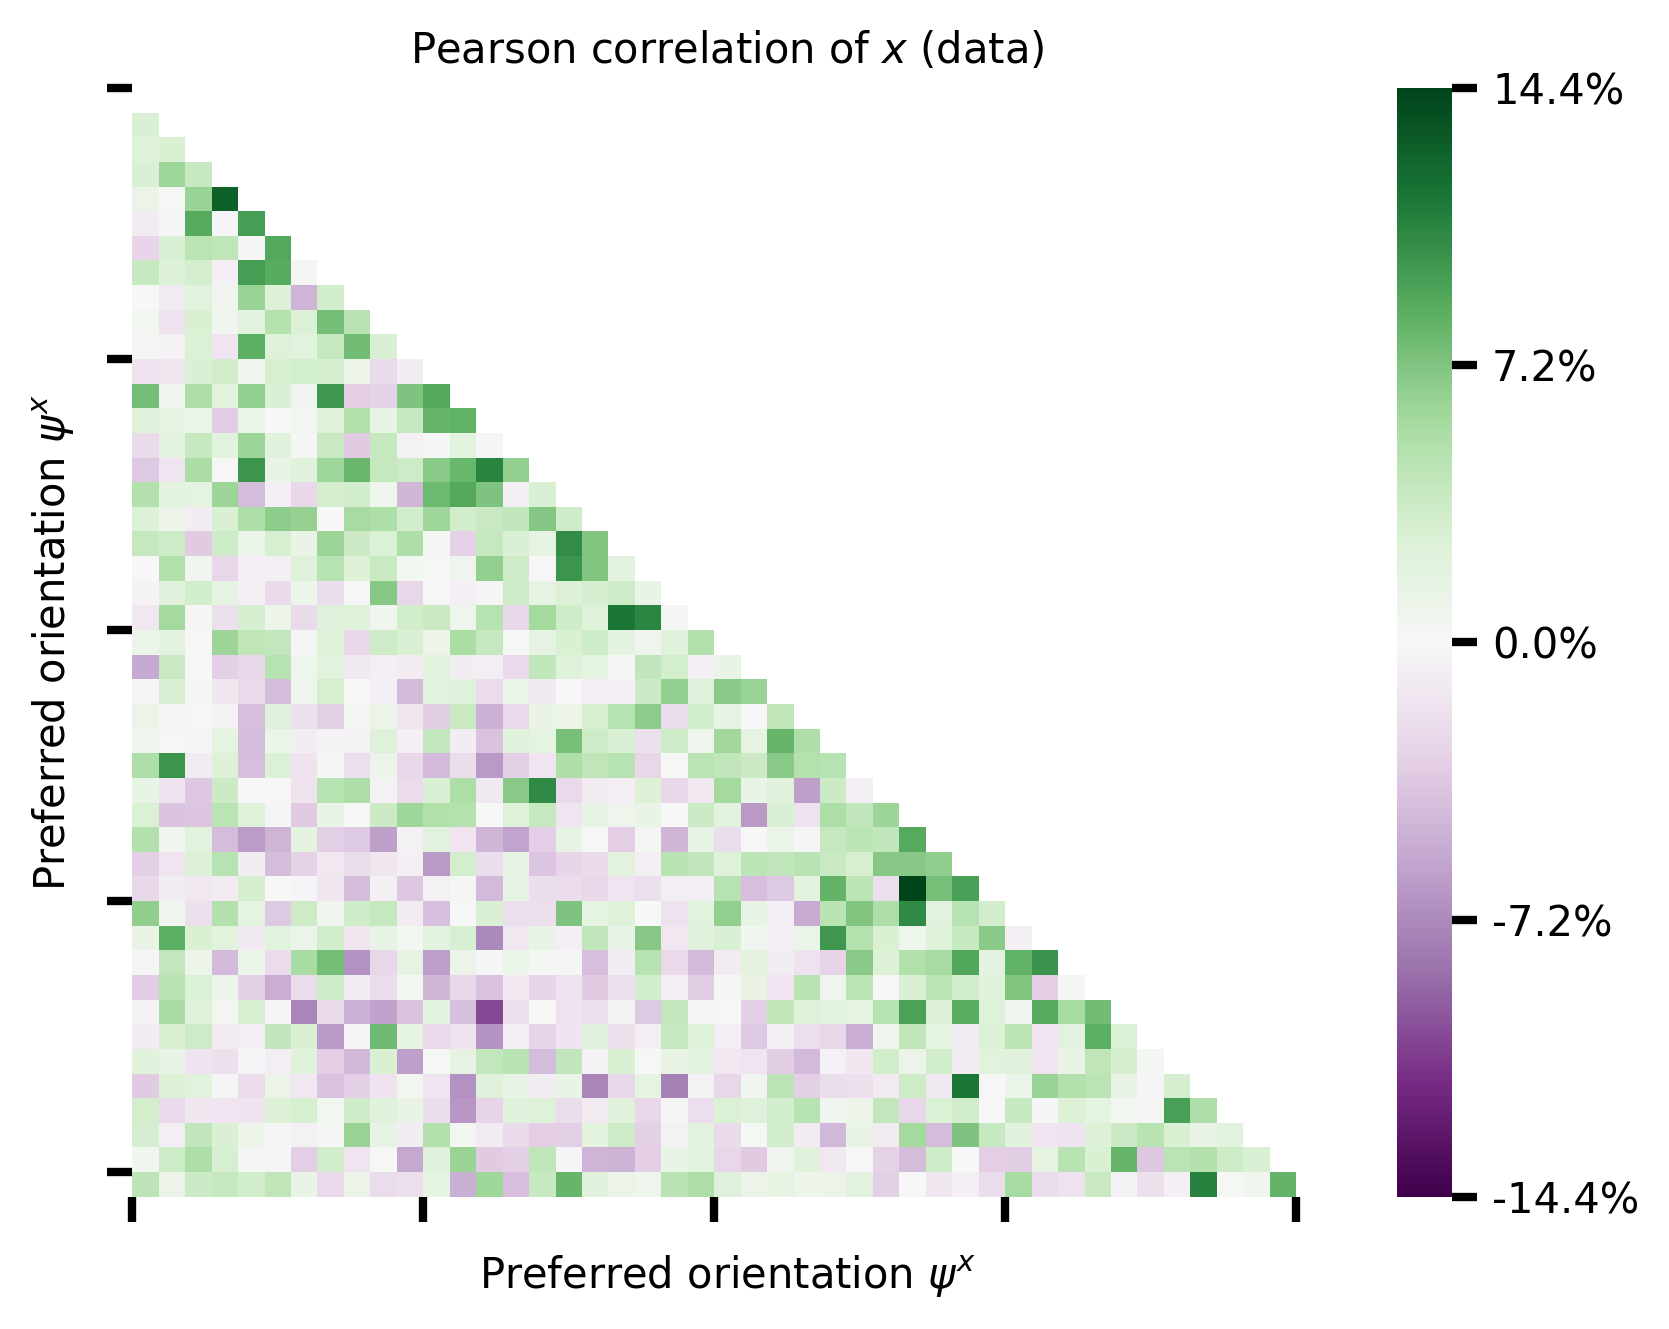

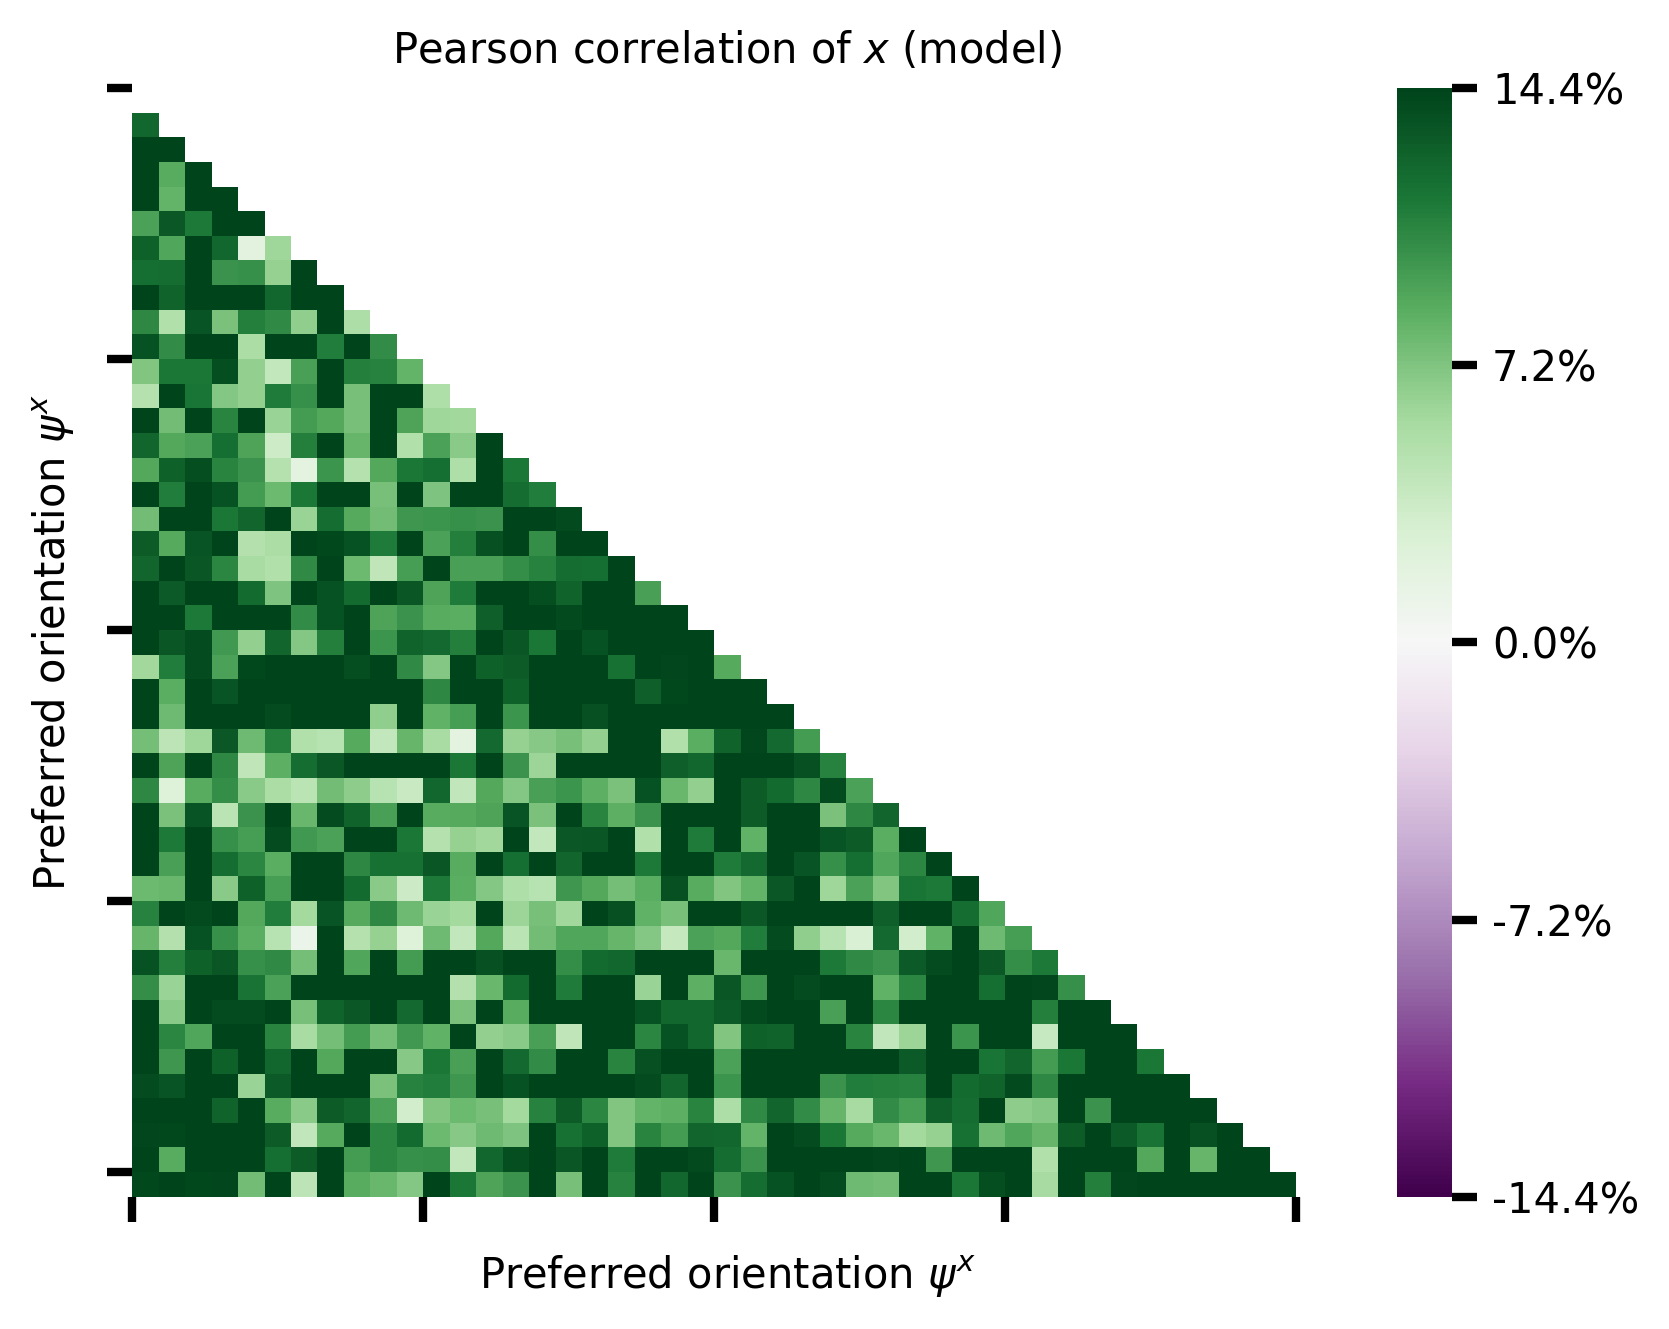

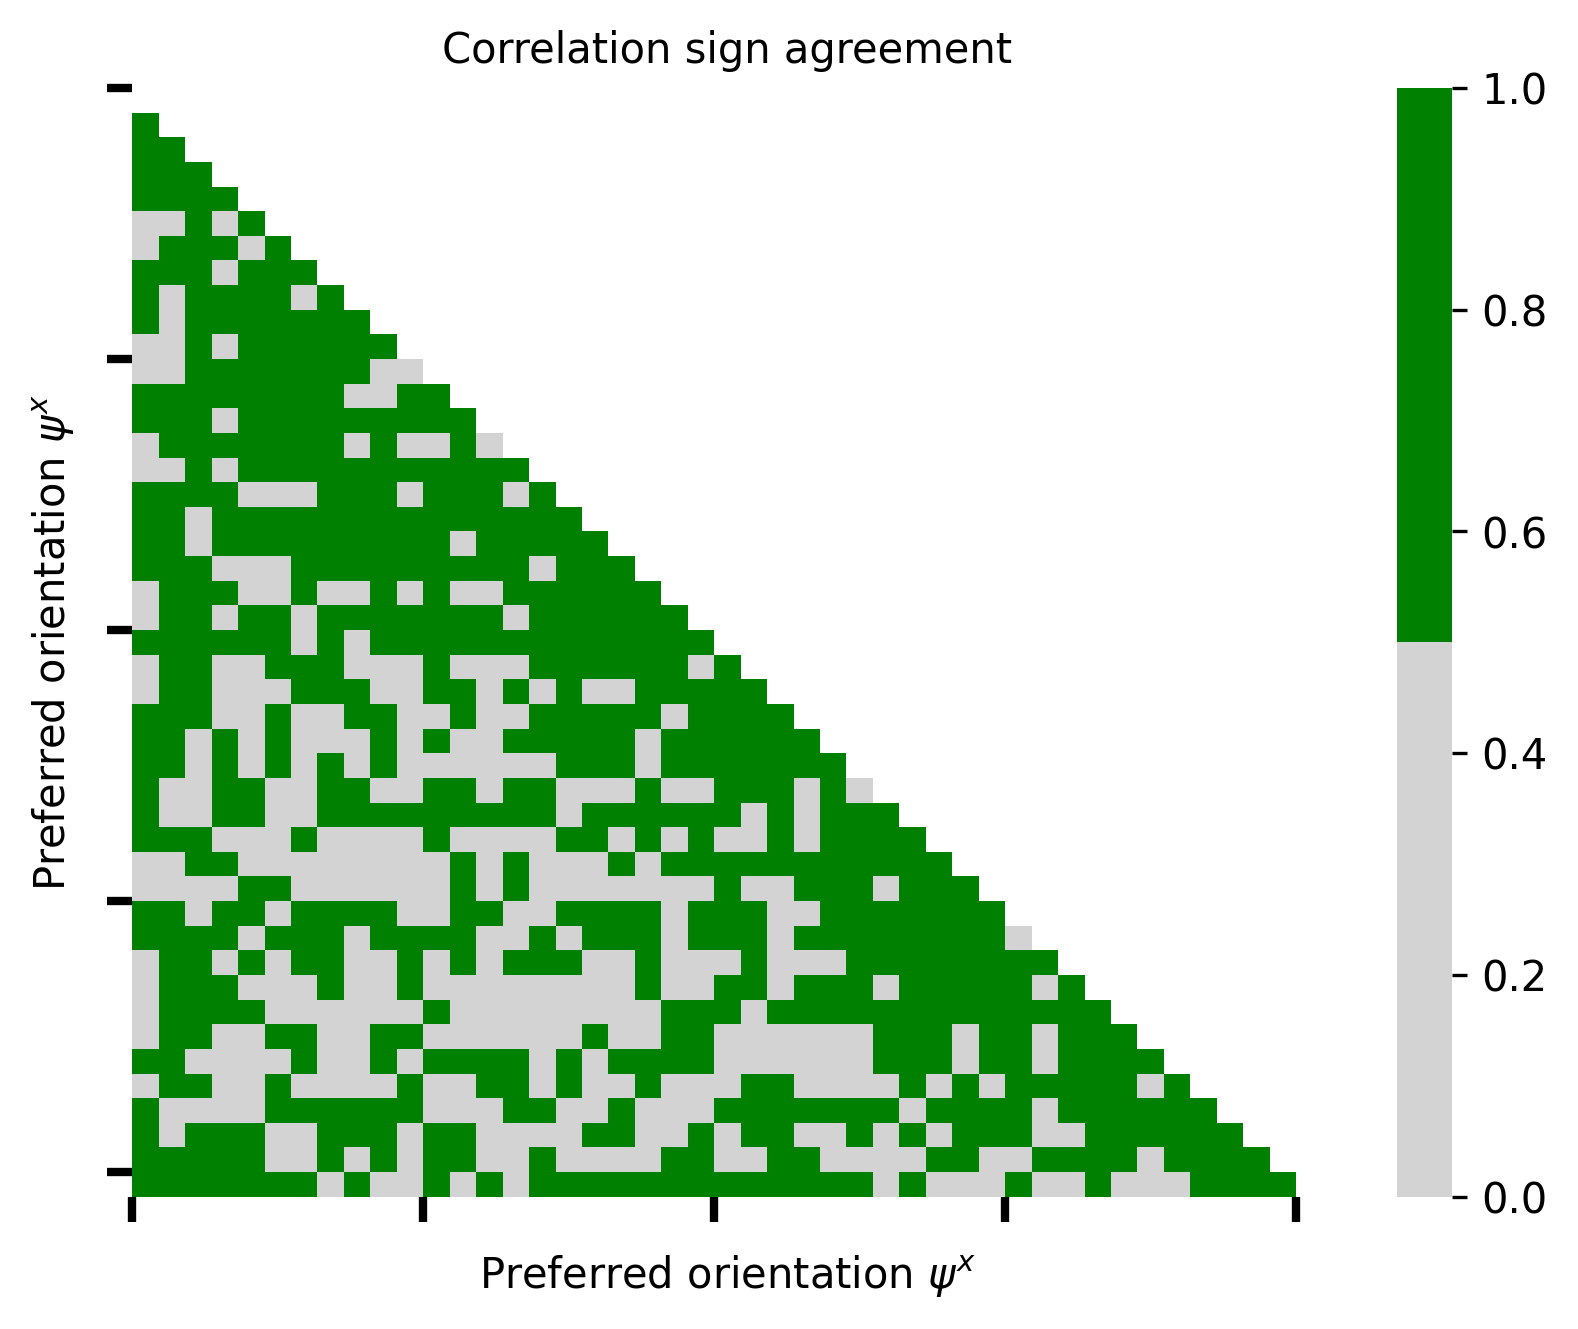

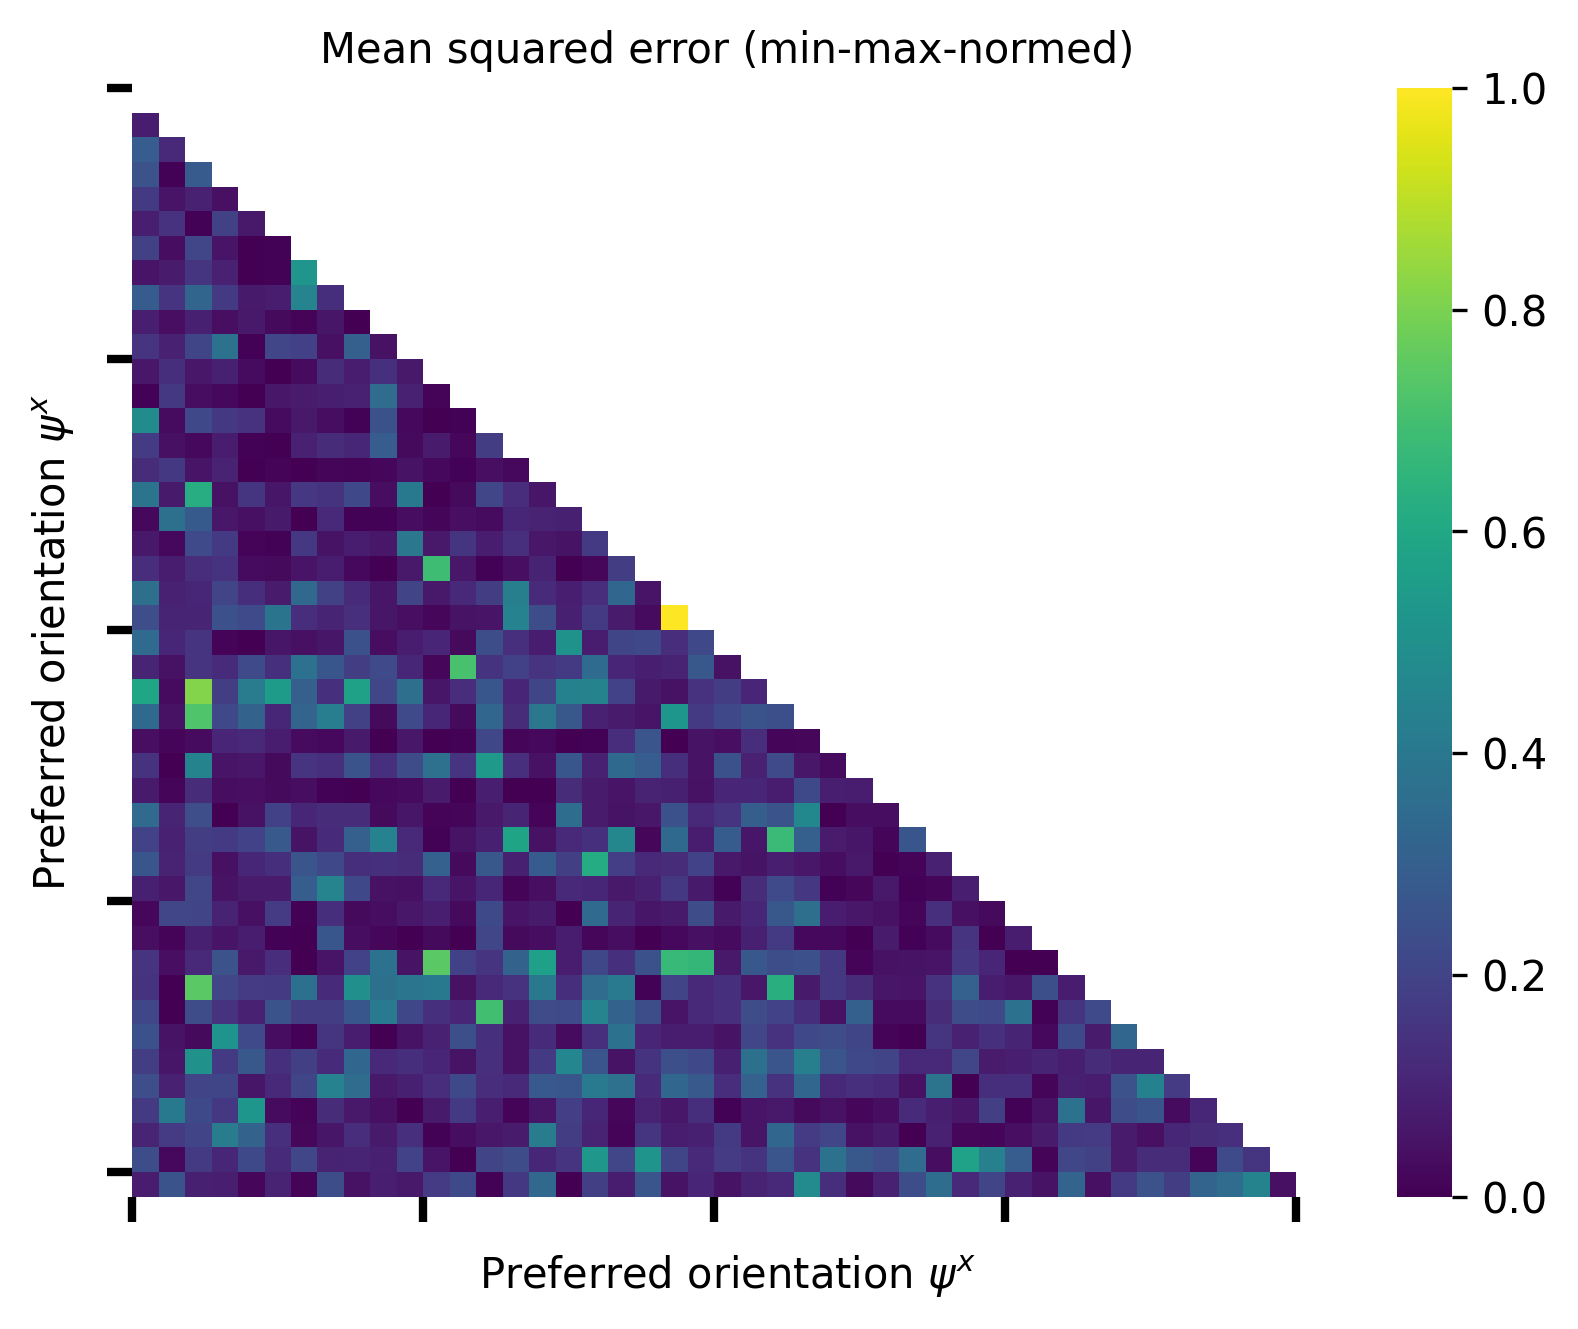

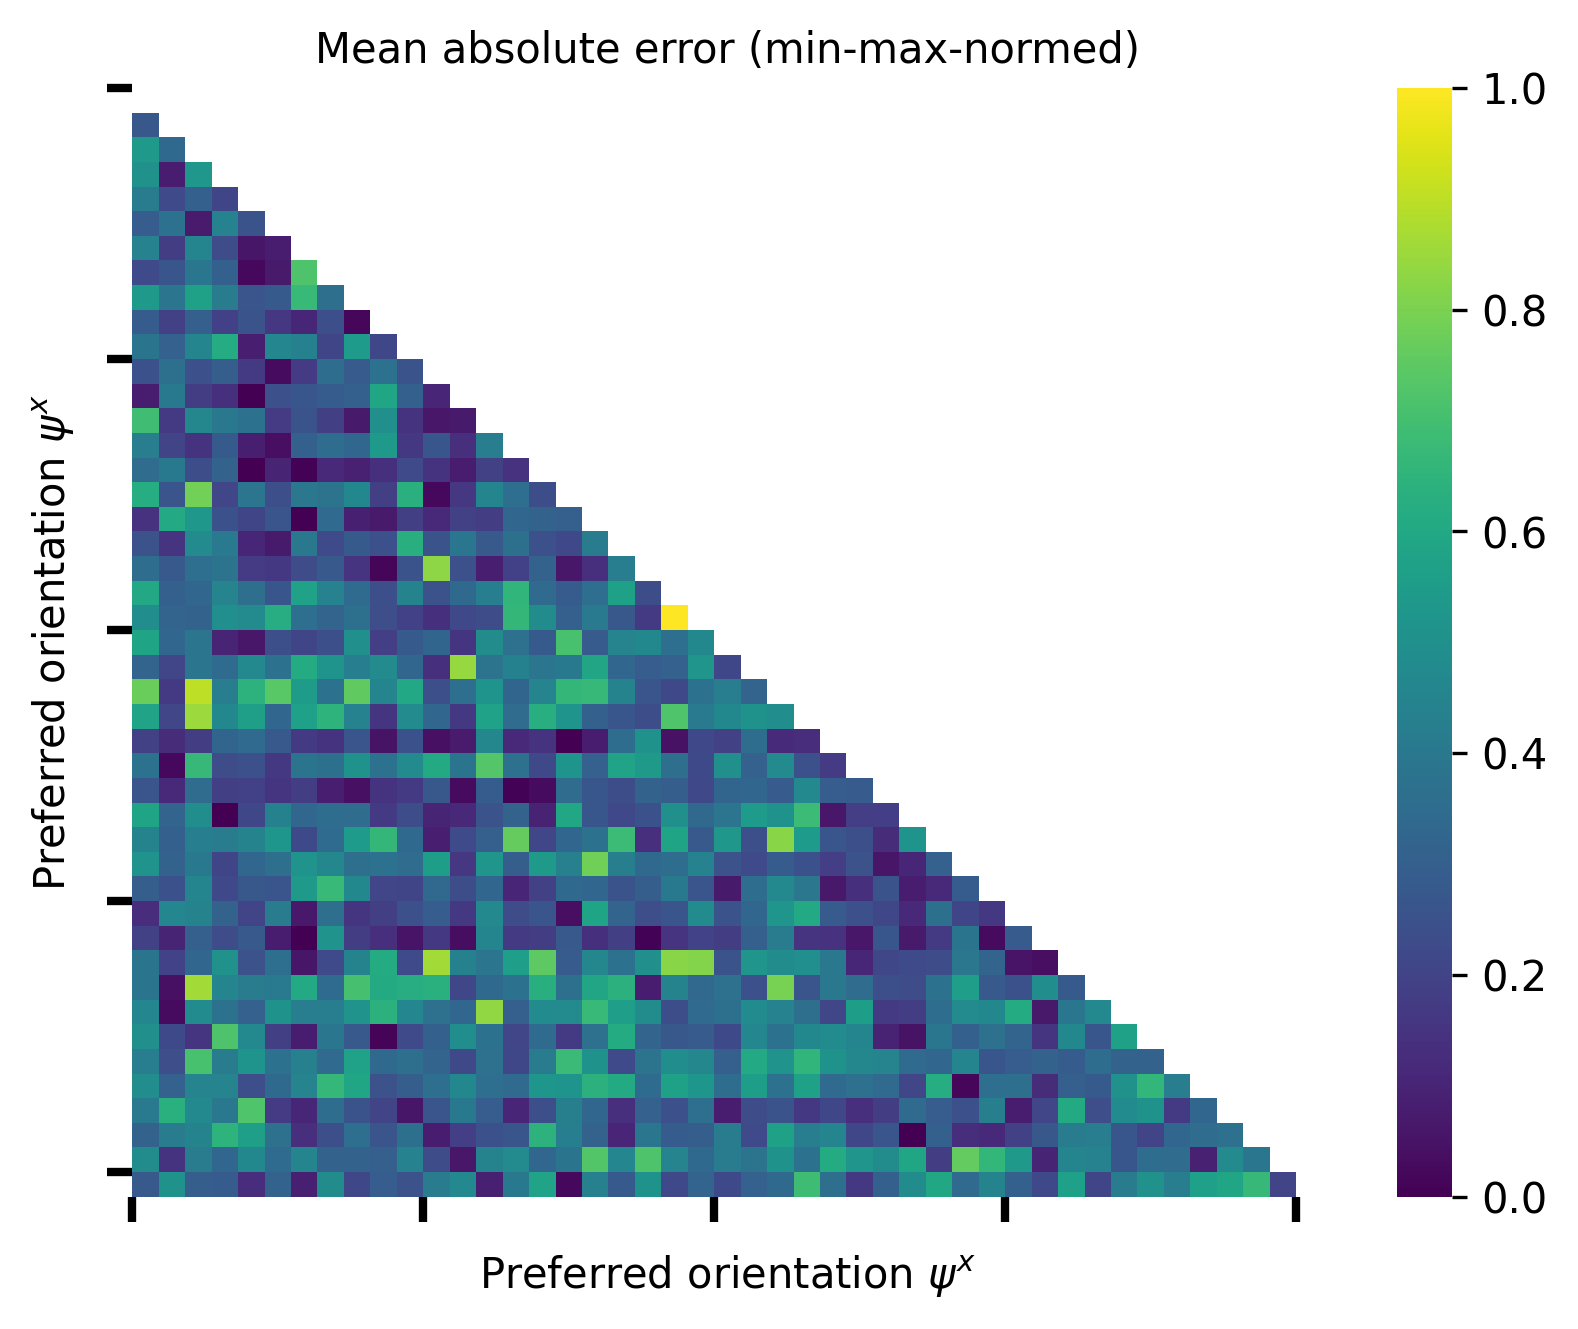

In [8]:
output = evaluate_flow_prior(flow_model, test_loader)

In [10]:
len(output)

22